<a href="https://colab.research.google.com/github/gurudattamanpreet/Practice/blob/main/after_train_test_split_airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score,mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/gurudattamanpreet/datasets/refs/heads/main/Airbnb_Open_Data.csv',low_memory=False)

In [3]:
df.shape

(102599, 26)

In [4]:
df.select_dtypes(include=['object']).nunique()

,0
NAME,61281
host_identity_verified,2
host name,13190
neighbourhood group,7
neighbourhood,224
country,1
country code,1
instant_bookable,2
cancellation_policy,3
room type,4


In [5]:
df['last review']=pd.to_datetime(df['last review'])

In [6]:
df['Month']=df['last review'].dt.month
df['Year']=df['last review'].dt.year

In [7]:
df.drop(['NAME','host name','neighbourhood','country code','country','license','id','host id','lat','long','last review','house_rules'],axis=1,inplace=True)

In [8]:
df.shape

(102599, 16)

In [9]:
df.select_dtypes(include=['object']).isna().sum()

,0
host_identity_verified,289
neighbourhood group,29
instant_bookable,105
cancellation_policy,76
room type,0
price,247
service fee,273


In [10]:
df.select_dtypes(include=['object']).nunique()

,0
host_identity_verified,2
neighbourhood group,7
instant_bookable,2
cancellation_policy,3
room type,4
price,1151
service fee,231


In [11]:
df['price']

,price
0,$966
1,$142
2,$620
3,$368
4,$204
...,...
102594,$844
102595,$837
102596,$988
102597,$546


In [12]:
df['price']=df['price'].str.replace('$','')
df['price']=df['price'].str.replace(',','').astype('float64')

In [13]:
df['service fee']=df['service fee'].str.replace('$','')
df['service fee']=df['service fee'].str.replace(',','').astype('float64')

In [14]:
df.dtypes

,0
host_identity_verified,object
neighbourhood group,object
instant_bookable,object
cancellation_policy,object
room type,object
Construction year,float64
price,float64
service fee,float64
minimum nights,float64
number of reviews,float64


In [15]:
df.select_dtypes(include=['object']).nunique()

,0
host_identity_verified,2
neighbourhood group,7
instant_bookable,2
cancellation_policy,3
room type,4


In [16]:
q=df.select_dtypes(include=['object']).columns.tolist()
for i in q:
  print(df[i].value_counts(),'\n')

host_identity_verified
unconfirmed    51200
verified       51110
Name: count, dtype: int64 

neighbourhood group
Manhattan        43792
Brooklyn         41842
Queens           13267
Bronx             2712
Staten Island      955
brookln              1
manhatan             1
Name: count, dtype: int64 

instant_bookable
False    51474
True     51020
Name: count, dtype: int64 

cancellation_policy
moderate    34343
strict      34106
flexible    34074
Name: count, dtype: int64 

room type
Entire home/apt    53701
Private room       46556
Shared room         2226
Hotel room           116
Name: count, dtype: int64 



In [17]:
df['neighbourhood group']=df['neighbourhood group'].str.replace('brookln','Brooklyn')
df['neighbourhood group']=df['neighbourhood group'].str.replace('manhatan','Manhattan')

In [18]:
df['neighbourhood group'].value_counts()

,count
neighbourhood group,
Manhattan,43793
Brooklyn,41843
Queens,13267
Bronx,2712
Staten Island,955


In [19]:
df.duplicated().sum()

np.int64(3636)

In [20]:
df=df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.shape

(98963, 16)

In [23]:
df.select_dtypes(include=['int64','float64']).nunique()

,0
Construction year,20
price,1151
service fee,231
minimum nights,153
number of reviews,476
reviews per month,1016
review rate number,5
calculated host listings count,78
availability 365,438
Month,12


In [24]:
df.dtypes

,0
host_identity_verified,object
neighbourhood group,object
instant_bookable,object
cancellation_policy,object
room type,object
Construction year,float64
price,float64
service fee,float64
minimum nights,float64
number of reviews,float64


<Axes: xlabel='reviews per month', ylabel='Count'>

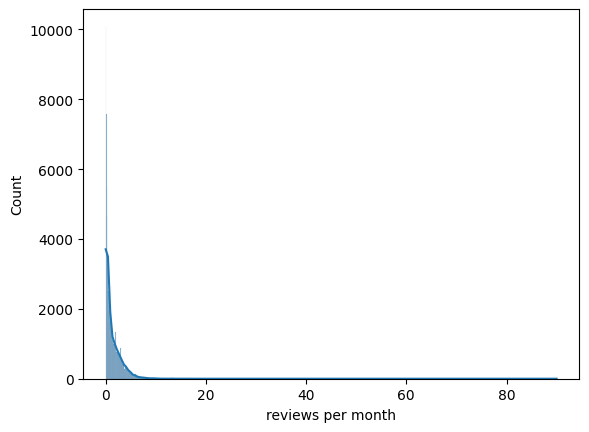

In [25]:
sns.histplot(df['reviews per month'],kde=True)

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Construction year,98749.0,2012.489028,5.766887,2003.00,2007.00,2012.00,2017.0,2022.0
price,98716.0,625.260252,331.767279,50.00,339.00,625.00,913.0,1200.0
service fee,98690.0,125.019191,66.344547,10.00,68.00,125.00,183.0,240.0
minimum nights,98565.0,8.167899,30.949651,-1223.00,2.00,3.00,5.0,5645.0
number of reviews,98783.0,27.588451,49.858876,0.00,1.00,7.00,30.0,1024.0
reviews per month,83625.0,1.375636,1.752274,0.01,0.22,0.74,2.0,90.0
review rate number,98650.0,3.282382,1.283631,1.00,2.00,3.00,4.0,5.0
calculated host listings count,98655.0,7.992094,32.355888,1.00,1.00,1.00,2.0,332.0
availability 365,98515.0,142.042004,135.476207,-10.00,4.00,99.00,270.0,3677.0
Month,83611.0,5.880961,3.031727,1.00,4.00,6.00,7.0,12.0


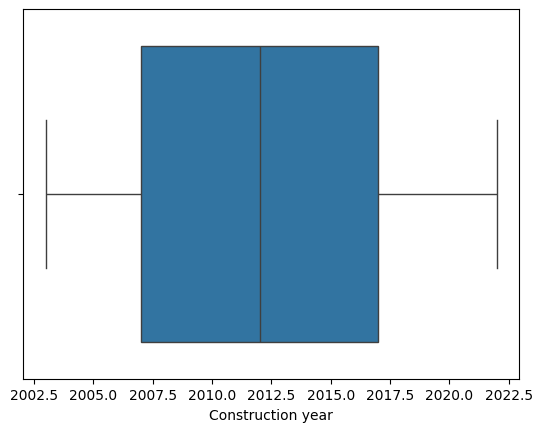

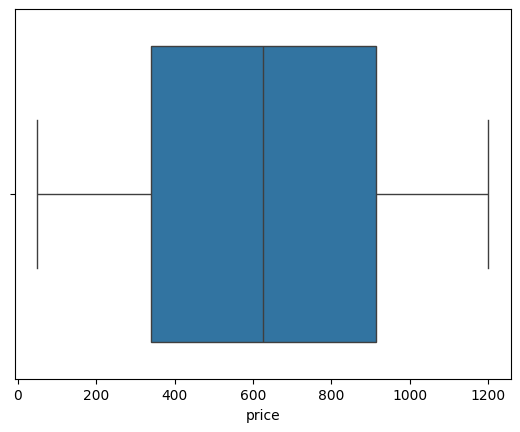

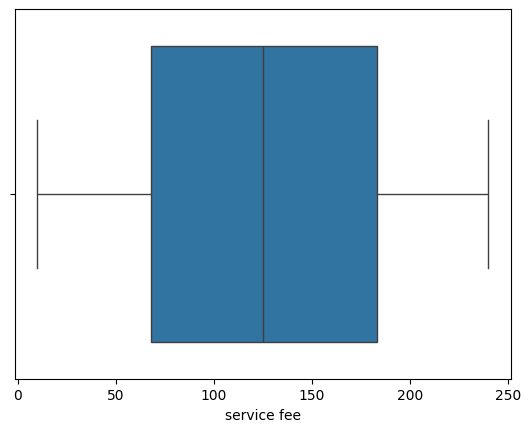

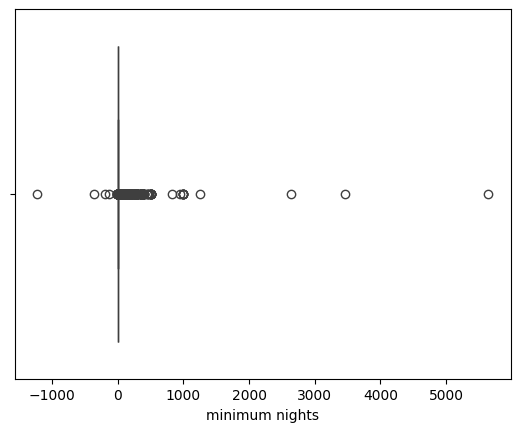

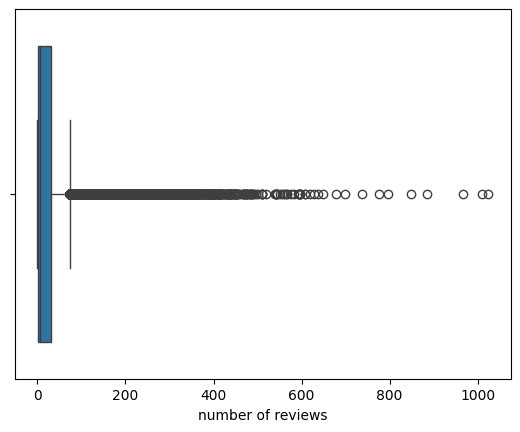

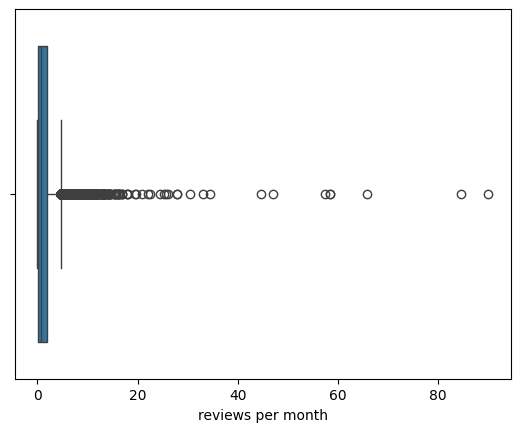

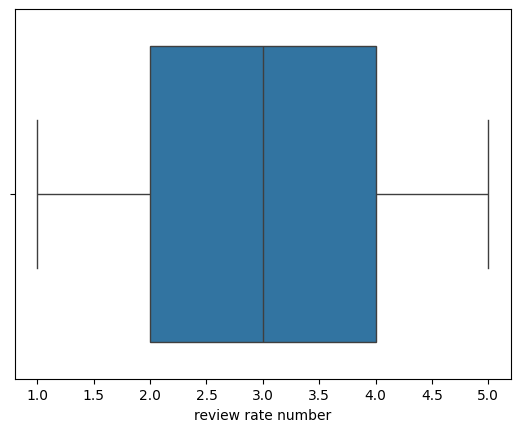

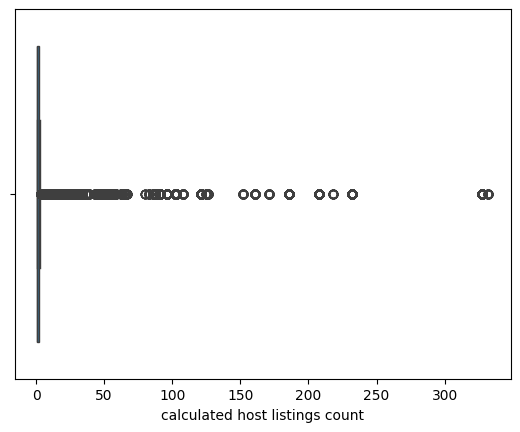

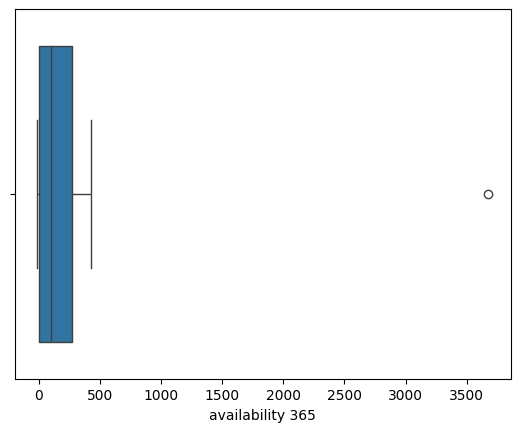

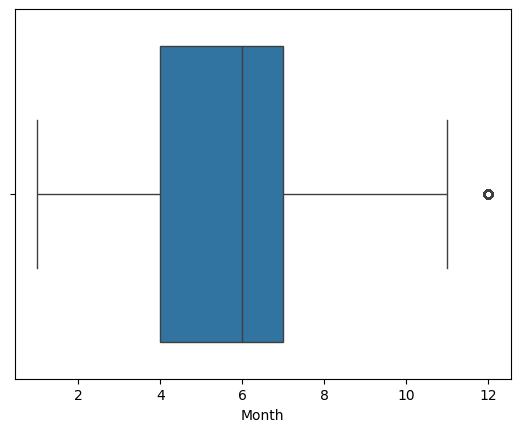

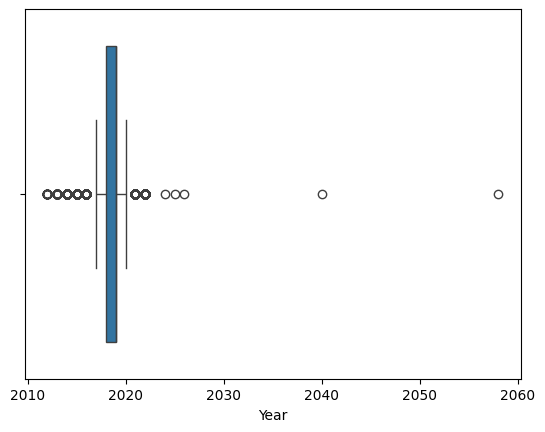

In [27]:
w=df.select_dtypes(include=['int64','float64']).columns.tolist()
for i in w:
  sns.boxplot(x=df[i])
  plt.show()

In [28]:
df.select_dtypes(include=['int64','float64']).columns.tolist()

['Construction year',
 'price',
 'service fee',
 'minimum nights',
 'number of reviews',
 'reviews per month',
 'review rate number',
 'calculated host listings count',
 'availability 365',
 'Month',
 'Year']

In [29]:
df.dtypes

,0
host_identity_verified,object
neighbourhood group,object
instant_bookable,object
cancellation_policy,object
room type,object
Construction year,float64
price,float64
service fee,float64
minimum nights,float64
number of reviews,float64


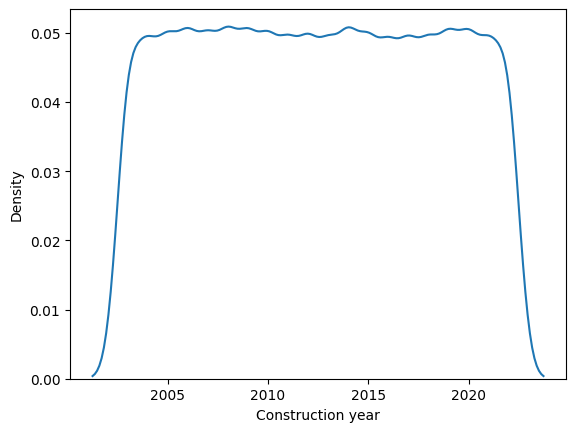

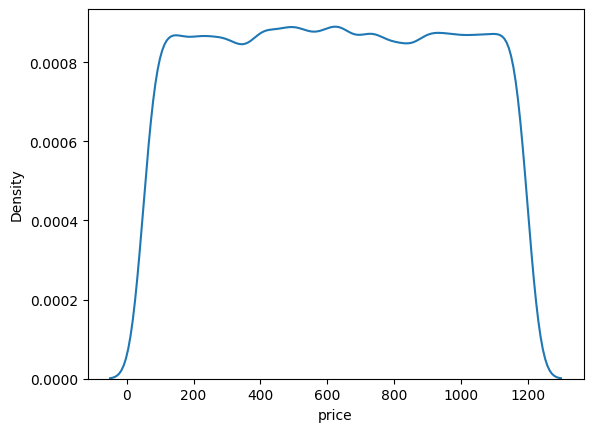

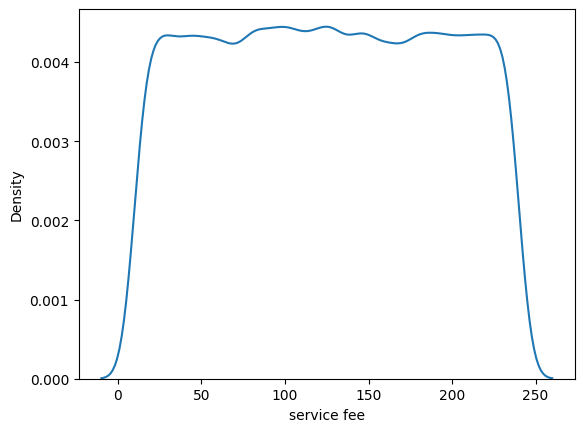

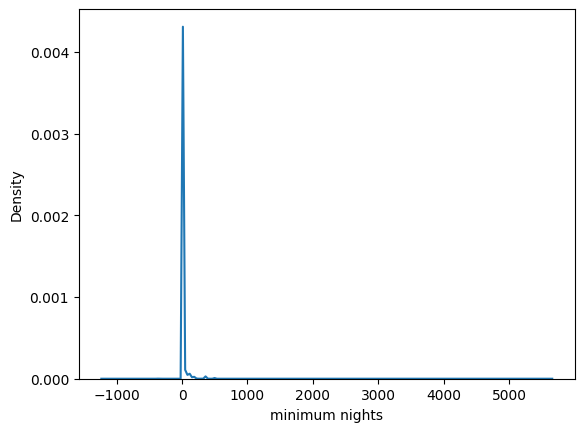

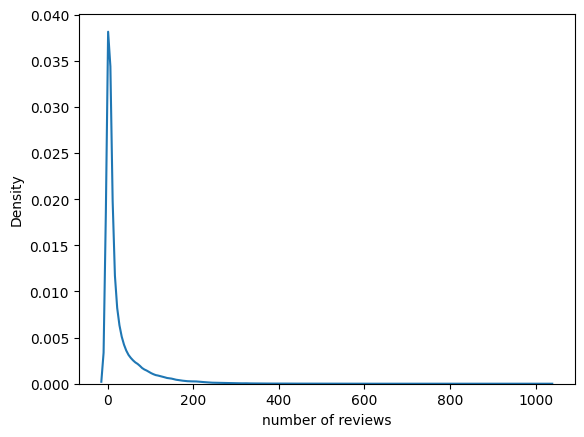

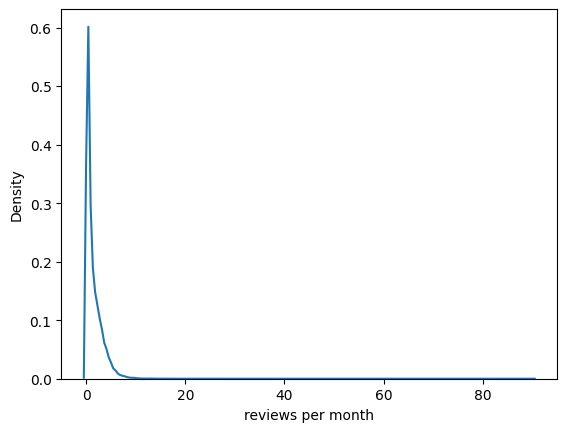

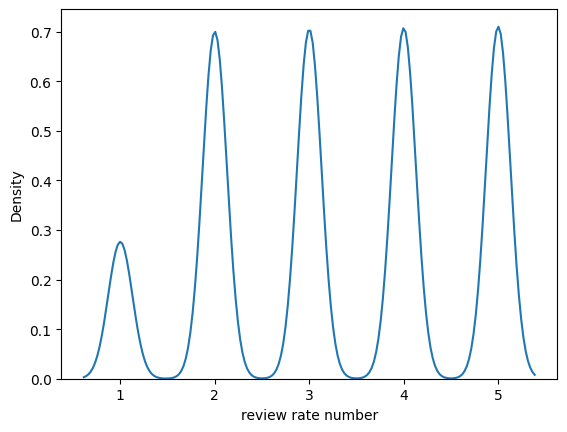

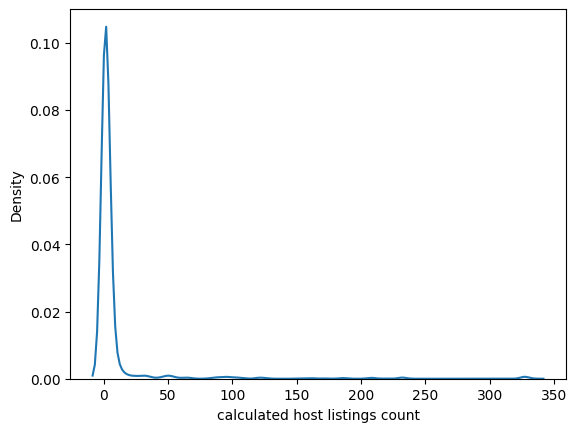

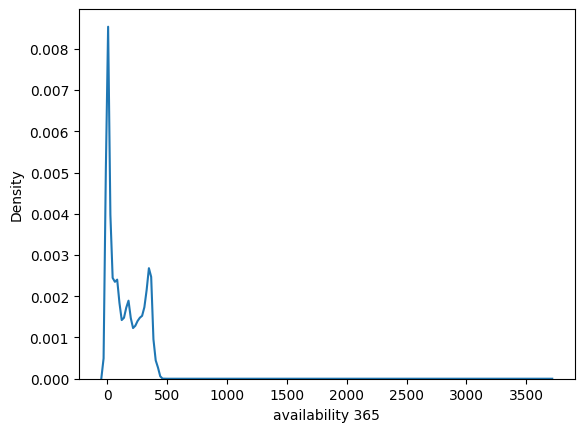

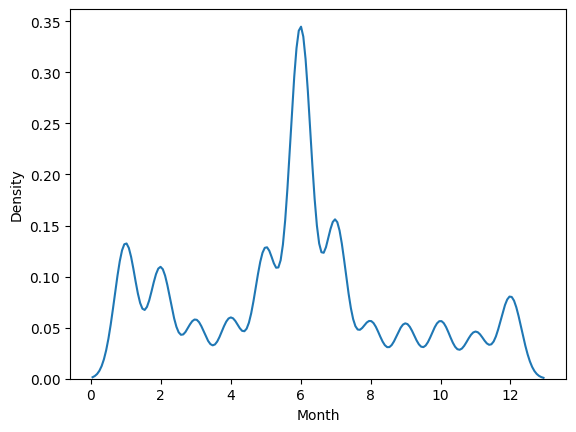

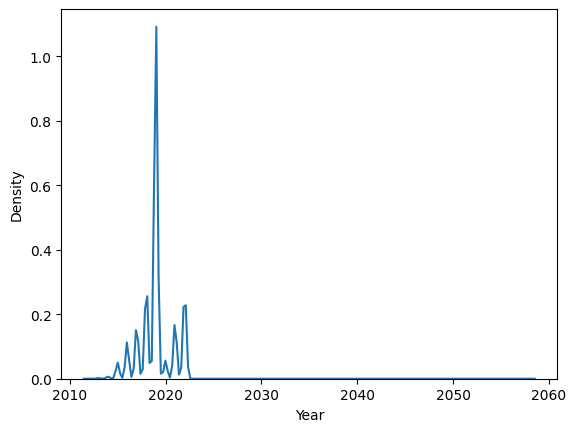

In [30]:
e=df.select_dtypes(include=['int64','float64']).columns.tolist()
for i in e:
  sns.kdeplot(df[i])
  plt.show()

    removing irrelevant values:

In [31]:
df.dtypes

,0
host_identity_verified,object
neighbourhood group,object
instant_bookable,object
cancellation_policy,object
room type,object
Construction year,float64
price,float64
service fee,float64
minimum nights,float64
number of reviews,float64


In [32]:
df.sort_values(by='Year',ascending=False).head(5)

,host_identity_verified,neighbourhood group,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,Month,Year
255,NaN,Brooklyn,True,moderate,Entire home/apt,2008.0,842.0,168.0,3.0,124.0,1.22,4.0,3.0,230.0,6.0,2058.0
483,verified,Manhattan,False,flexible,Private room,NaN,721.0,144.0,2.0,41.0,0.43,3.0,2.0,47.0,6.0,2040.0
318,verified,Brooklyn,True,flexible,Private room,2018.0,920.0,184.0,2.0,1.0,0.01,3.0,1.0,73.0,3.0,2026.0
191,unconfirmed,Manhattan,False,moderate,Entire home/apt,NaN,539.0,108.0,NaN,41.0,0.38,2.0,1.0,NaN,6.0,2025.0
127,unconfirmed,Manhattan,False,strict,Entire home/apt,2007.0,571.0,114.0,5.0,21.0,0.19,4.0,NaN,395.0,8.0,2024.0


In [33]:
df[df['Year'].isin([2058,2040,2026,2025])]

,host_identity_verified,neighbourhood group,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,Month,Year
191,unconfirmed,Manhattan,False,moderate,Entire home/apt,NaN,539.0,108.0,NaN,41.0,0.38,2.0,1.0,NaN,6.0,2025.0
255,NaN,Brooklyn,True,moderate,Entire home/apt,2008.0,842.0,168.0,3.0,124.0,1.22,4.0,3.0,230.0,6.0,2058.0
318,verified,Brooklyn,True,flexible,Private room,2018.0,920.0,184.0,2.0,1.0,0.01,3.0,1.0,73.0,3.0,2026.0
483,verified,Manhattan,False,flexible,Private room,NaN,721.0,144.0,2.0,41.0,0.43,3.0,2.0,47.0,6.0,2040.0


In [34]:
df['price'].isna().sum()

np.int64(247)

In [35]:
df.dtypes

,0
host_identity_verified,object
neighbourhood group,object
instant_bookable,object
cancellation_policy,object
room type,object
Construction year,float64
price,float64
service fee,float64
minimum nights,float64
number of reviews,float64


In [36]:
df=df[df['price'].notna()]

In [37]:
df['price'].isna().sum()

np.int64(0)

In [38]:
df['price'].shape

(98716,)

In [39]:
df['price'].dtypes

dtype('float64')

In [40]:
df.dtypes

,0
host_identity_verified,object
neighbourhood group,object
instant_bookable,object
cancellation_policy,object
room type,object
Construction year,float64
price,float64
service fee,float64
minimum nights,float64
number of reviews,float64


In [41]:
df.dtypes

,0
host_identity_verified,object
neighbourhood group,object
instant_bookable,object
cancellation_policy,object
room type,object
Construction year,float64
price,float64
service fee,float64
minimum nights,float64
number of reviews,float64


In [42]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

,price
price,1.000000
service fee,0.999991
number of reviews,0.004896
reviews per month,0.004164
Year,0.001224
calculated host listings count,0.000621
availability 365,-0.001918
minimum nights,-0.003093
Construction year,-0.003807
Month,-0.003818


In [43]:
(df['service fee'] / df['price']).describe()

,0
count,98477.000000
mean,0.199993
std,0.001151
min,0.192308
25%,0.199609
50%,0.200000
75%,0.200389
max,0.207547


    Std ≈ 0.001 or less
    Toh ye feature target ka almost duplicate hai = leakage
    target variable price ka bhai baitha hua h independent variable me as service fee
    Feature ko drop kr dena chahiye
    target varible ki nakal wala koi bhi independent me nhi hona chahiye
    agar he to wo data leakage kr rha h

<Axes: >

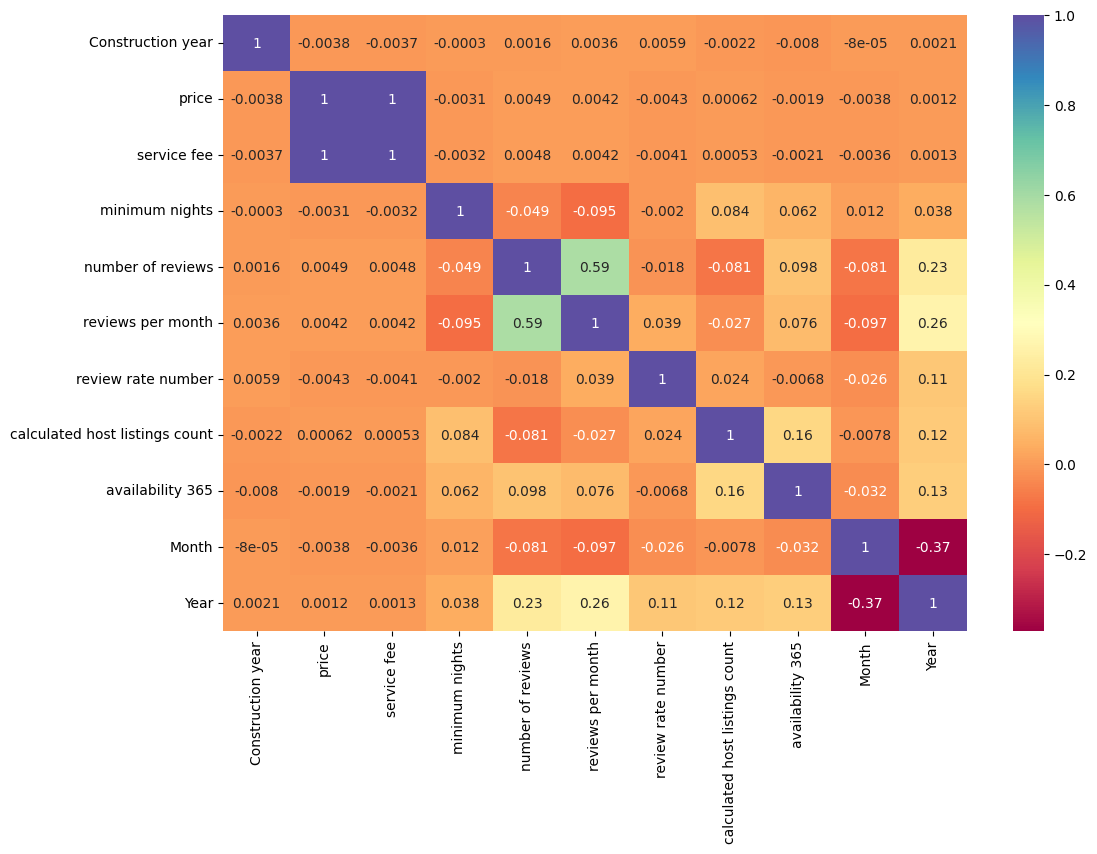

In [44]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),annot=True,cmap='Spectral')

In [45]:
df.select_dtypes(include=['int64','float64']).nunique()

,0
Construction year,20
price,1151
service fee,231
minimum nights,153
number of reviews,476
reviews per month,1016
review rate number,5
calculated host listings count,78
availability 365,438
Month,12


In [46]:
df.dtypes

,0
host_identity_verified,object
neighbourhood group,object
instant_bookable,object
cancellation_policy,object
room type,object
Construction year,float64
price,float64
service fee,float64
minimum nights,float64
number of reviews,float64


In [47]:
df['listing age']=df['Year']-df['Construction year']
df['price_per_night'] = df['price'] / df['minimum nights']
df['review_activity'] = df['reviews per month'] * df['number of reviews']
df['booking_intensity'] = df['availability 365'] / df['minimum nights']
df['is_verified_host'] = (df['host_identity_verified'] == 'verified').astype(int)
df['has_review_rate'] = df['review rate number'].notna().astype(int)

In [48]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

,price
price,1.000000
service fee,0.999991
price_per_night,0.529968
number of reviews,0.004896
listing age,0.004302
has_review_rate,0.004238
reviews per month,0.004164
Year,0.001224
calculated host listings count,0.000621
booking_intensity,-0.000217


<Axes: >

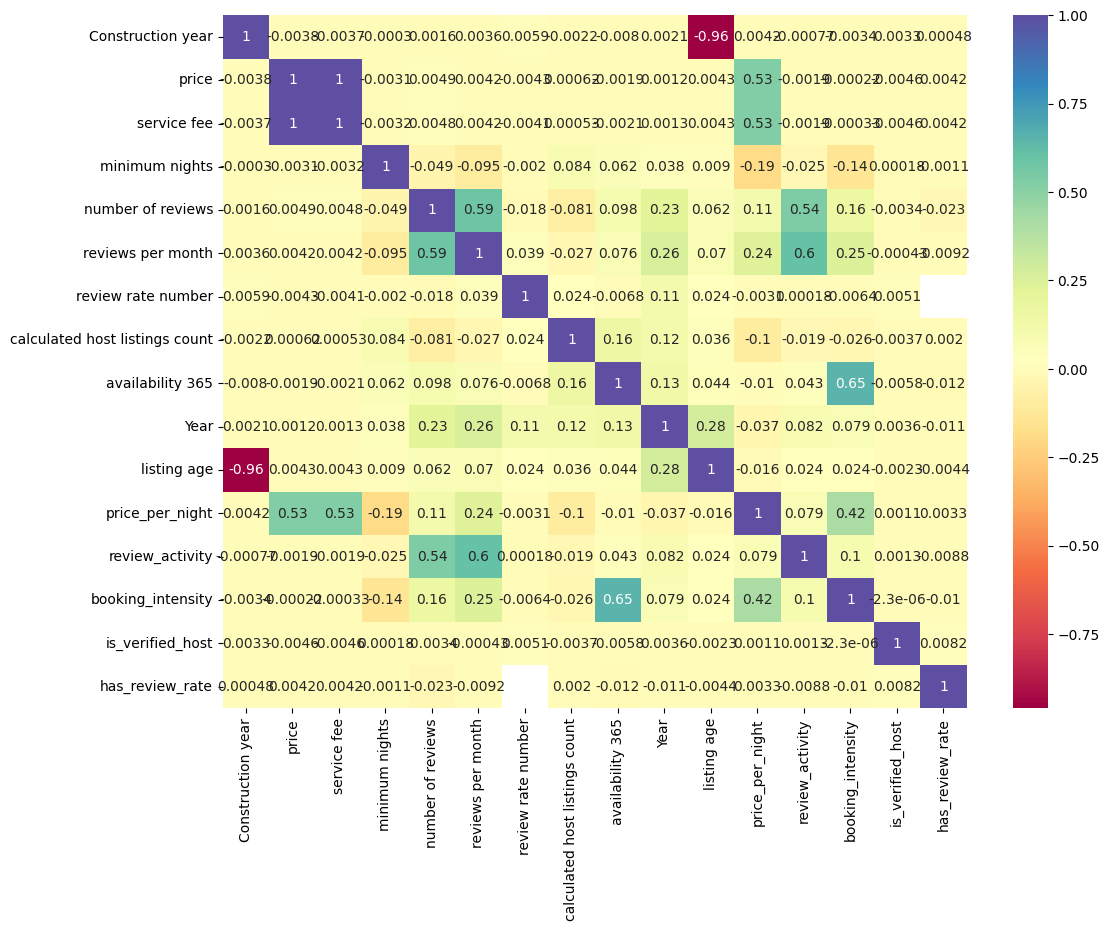

In [91]:
plt.figure(figsize=(12,9))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),annot=True,cmap='Spectral')

In [50]:
df.drop(['Month','service fee'],axis=1,inplace=True)

In [51]:
X=df.drop(['price'],axis=1)
y=df['price']

In [52]:
y.dtypes

dtype('float64')

In [53]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [54]:
# X_train = X_train.drop(columns='service fee')
# X_test = X_test.drop(columns='service fee')

In [55]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [56]:
X_train.select_dtypes(include=['object']).isna().sum()

,0
host_identity_verified,215
neighbourhood group,20
instant_bookable,69
cancellation_policy,49
room type,0


In [57]:
w=X_train.select_dtypes(include=['int64','float64']).columns.tolist()
si=SimpleImputer(strategy='median')
X_train_num=si.fit_transform(X_train[w])
X_test_num=si.transform(X_test[w])

In [58]:
e=X_train.select_dtypes(include=['object']).columns.tolist()
si2=SimpleImputer(strategy='most_frequent')
X_train_obj=si2.fit_transform(X_train[e])
X_test_obj=si2.transform(X_test[e])

In [59]:
# Convert both to DataFrames
X_train_num = pd.DataFrame(X_train_num, columns=w, index=X_train.index)
X_test_num = pd.DataFrame(X_test_num, columns=w, index=X_test.index)

X_train_obj = pd.DataFrame(X_train_obj, columns=e, index=X_train.index)
X_test_obj = pd.DataFrame(X_test_obj, columns=e, index=X_test.index)

# Combine both parts
X_train_imputed = pd.concat([X_train_num, X_train_obj], axis=1)
X_test_imputed = pd.concat([X_test_num, X_test_obj], axis=1)

In [60]:
# X_train_imputed['service fee'] / y_train_log

In [61]:
# (X_train['service fee'] / y_train).describe()

In [62]:
X_train_imputed.shape

(78972, 19)

In [63]:
X_test_imputed.shape

(19744, 19)

In [64]:
s=X_train_imputed.select_dtypes(include=['int64','float64'])
Q1=s.quantile(0.25)
Q3=s.quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-(1.5*IQR)
upper_bound=Q3+(1.5*IQR)
lower_outlier=s<lower_bound
upper_outlier=s>upper_bound

In [65]:
print(lower_outlier.sum())

Construction year                     0
minimum nights                        8
number of reviews                     0
reviews per month                     0
review rate number                    0
calculated host listings count        0
availability 365                      0
Year                              18667
listing age                           0
price_per_night                       0
review_activity                       0
booking_intensity                     1
is_verified_host                      0
has_review_rate                     250
dtype: int64


In [66]:
print(upper_outlier.sum())

Construction year                     0
minimum nights                    14214
number of reviews                  9095
reviews per month                  5492
review rate number                    0
calculated host listings count    13762
availability 365                      1
Year                              15168
listing age                           1
price_per_night                    4718
review_activity                   12504
booking_intensity                  6438
is_verified_host                      0
has_review_rate                       0
dtype: int64


In [67]:
X_train.select_dtypes(include=['int64', 'float64']).isna().sum().loc[lambda x: x > 0].index.tolist()

['Construction year',
 'minimum nights',
 'number of reviews',
 'reviews per month',
 'review rate number',
 'calculated host listings count',
 'availability 365',
 'Year',
 'listing age',
 'price_per_night',
 'review_activity',
 'booking_intensity']

In [68]:
X_train.select_dtypes(include=['int64','float64']).isna().sum().loc[lambda x: x > 0]

,0
Construction year,173
minimum nights,312
number of reviews,151
reviews per month,12293
review rate number,250
calculated host listings count,234
availability 365,375
Year,12308
listing age,12456
price_per_night,312


In [69]:
# train ka lower/upper bound test me bhi jaayega
v=X_train.select_dtypes(include=['int64', 'float64']).isna().sum().loc[lambda x: x > 0].index.tolist()
for i in v:
  lb=lower_bound[i]
  ub=upper_bound[i]
  X_train_imputed[i]=X_train_imputed[i].clip(lower=lb,upper=ub)
  X_test_imputed[i]=X_test_imputed[i].clip(lower=lb,upper=ub)

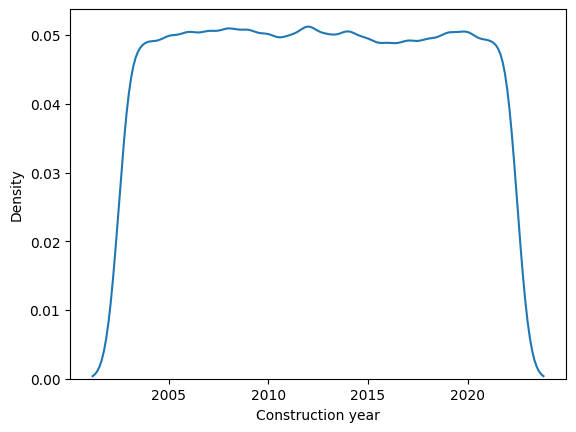

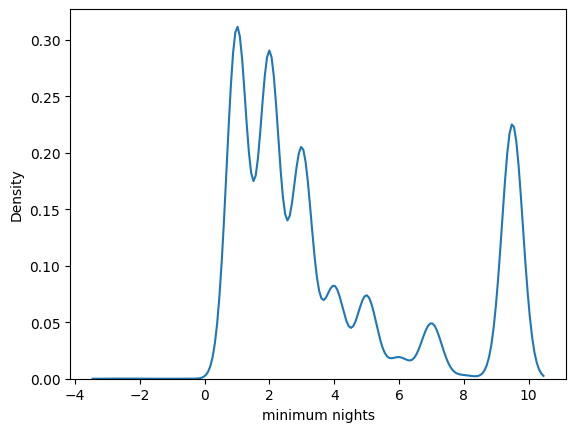

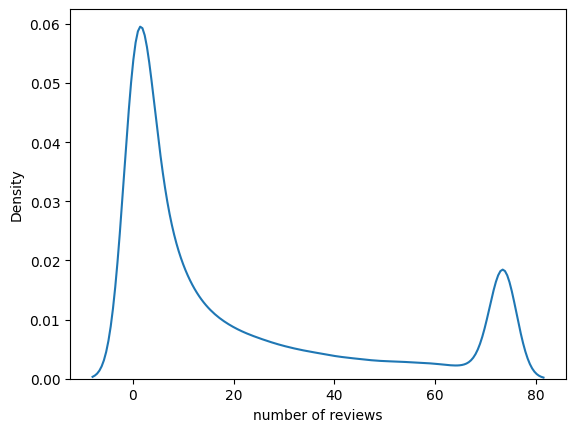

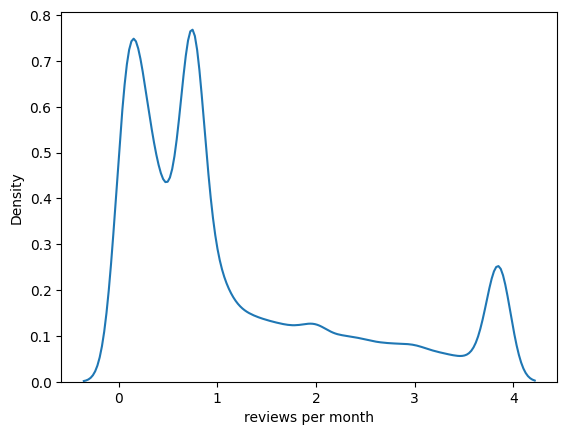

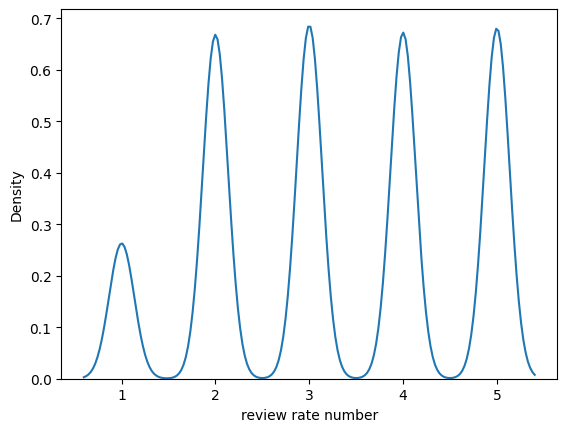

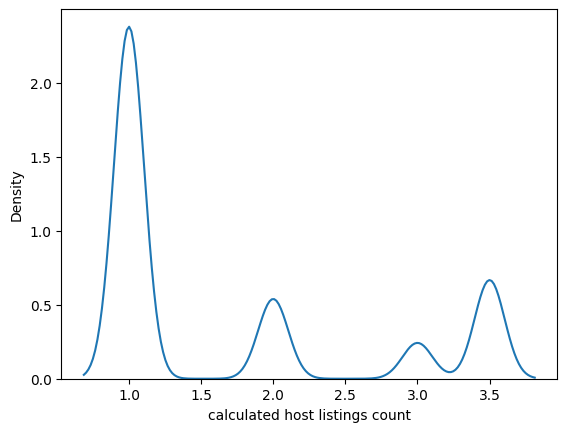

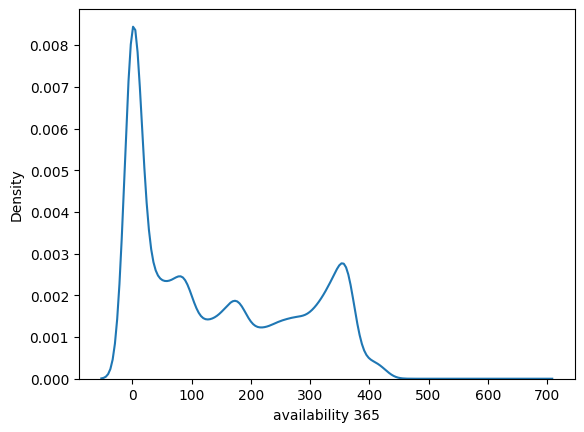

<ipython-input-70-772d7cac1392>:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(X_train_imputed[i])


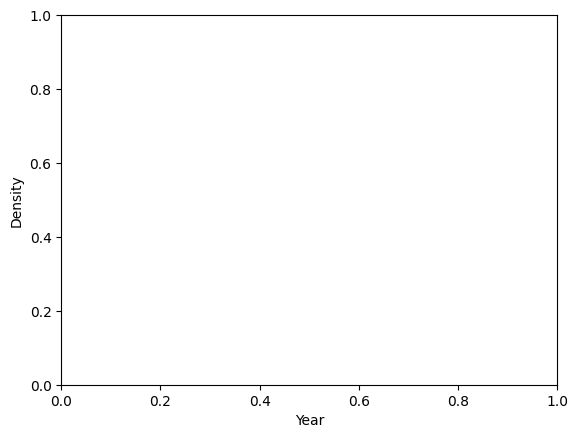

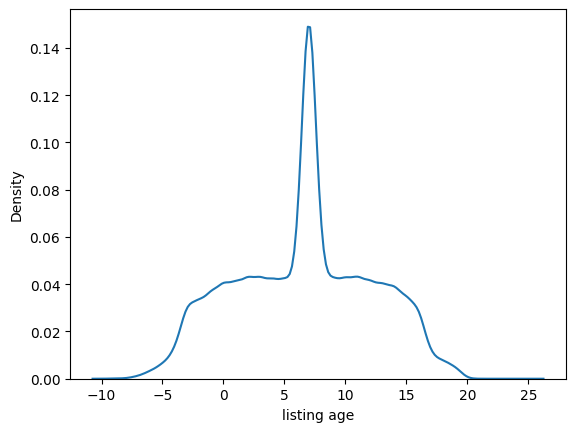

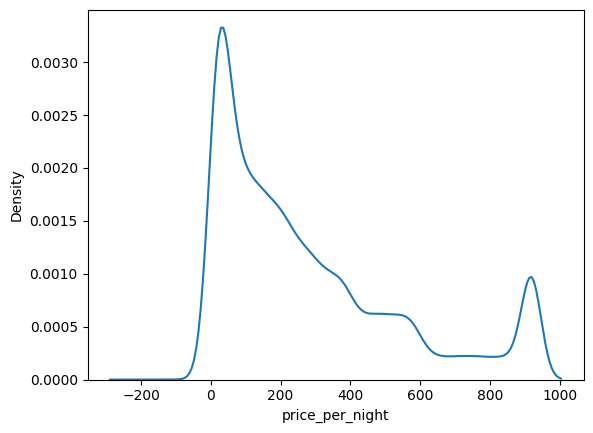

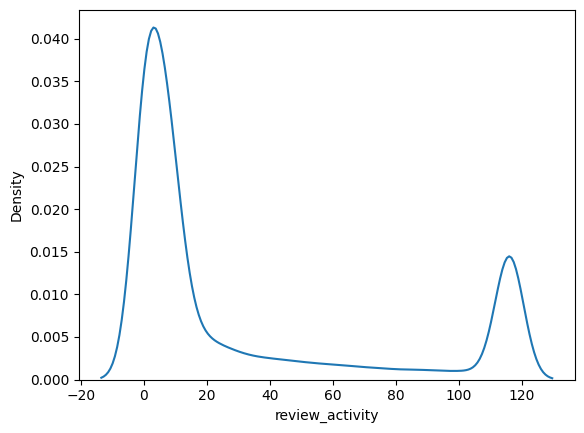

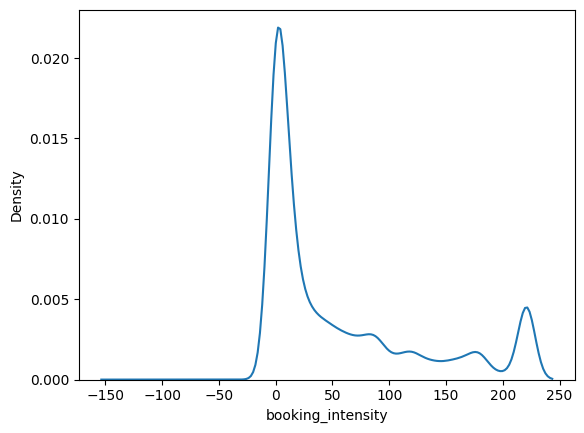

In [70]:
for i in v:
  sns.kdeplot(X_train_imputed[i])
  plt.show()

In [71]:
r=X_train_imputed.select_dtypes(include=['object']).columns.tolist()
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
ct=ColumnTransformer(transformers=[('ohe',ohe,r)],remainder='passthrough')

X_train_encoded_df = ct.fit_transform(X_train_imputed)
X_test_encoded_df = ct.transform(X_test_imputed)


feature_names = ct.get_feature_names_out()


X_train_encoded = pd.DataFrame(X_train_encoded_df, columns=feature_names, index=X_train_imputed.index)
X_test_encoded = pd.DataFrame(X_test_encoded_df, columns=feature_names, index=X_test_imputed.index)

In [72]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train_encoded)
X_test_scaled = sc.transform(X_test_encoded)

In [73]:
y_train_log.shape

(78972,)

In [74]:
X_train_scaled.shape

(78972, 25)

In [75]:
y_test_log.isna().sum()

np.int64(0)

In [76]:
y_train_log.isna().sum()

np.int64(0)

In [93]:
lr=LinearRegression()
lr.fit(X_train_scaled,y_train_log)

LinearRegression()

In [78]:
y_train_pred=lr.predict(X_train_scaled)
y_test_pred=lr.predict(X_test_scaled)

In [79]:
r2_score(y_train_log,y_train_pred)

0.4704879455269396

In [80]:
r2_score(y_test_log,y_test_pred)

0.4573521805398322

    Bhai… leakage(service fee) hatate hi model ki asli aukaat saamne aa gayi
    Aur yeh exactly wahi hota hai jab model sirf cheat kar raha hota hai, aur uska real signal zero ke aaspaas hota hai.

    High R² (like 0.99) with real-world noisy data is a red flag, not a badge of honor

    “Garbage in, garbage out” — agar features target ke baare me kuch batate hi nahi,
    to koi bhi model fail karega, chahe woh Linear ho ya XGBoost ya Neural Net.

In [81]:
mean_absolute_percentage_error(y_test_log,y_test_pred)

0.07303397111813618

In [82]:
mean_absolute_percentage_error(y_train_log,y_train_pred)

0.07280315631699075

In [83]:
rf = RandomForestRegressor(random_state=1)
rf.fit(X_train_scaled, y_train_log)

RandomForestRegressor(random_state=1)

In [84]:
y_train_rf=rf.predict(X_train_scaled)
y_test_rf=rf.predict(X_test_scaled)

In [85]:
r2_score(y_test_log,y_test_rf)

0.983068451221758

In [86]:
r2_score(y_train_log,y_train_rf)

0.9978757115558134

In [87]:
mean_absolute_percentage_error(y_test_log,y_test_rf)

0.0035020160351750818

In [88]:
y_test_log.describe()

,price
count,19744.000000
mean,6.228703
std,0.730252
min,3.931826
25%,5.823046
50%,6.428105
75%,6.816736
max,7.090910


    Min is 50, Max is 1200 >> long tail